In [14]:
# -*- coding: utf-8 -*-
"""
Drug reviews — T5 inference and evaluation

Loads a fine-tuned seq2seq T5 checkpoint (see T5_drugreview_finetune.ipynb), runs generation on
held-out val/test CSVs, and reports metrics and confusion matrices. Paths default to Colab Drive
when COLAB_RELEASE_TAG is set; otherwise uses the current directory.
"""

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
	AutoTokenizer,
	AutoModelForSeq2SeqLM,
	Seq2SeqTrainer,
	Seq2SeqTrainingArguments,
	DataCollatorForSeq2Seq
)
from sklearn.metrics import (
	classification_report,
	accuracy_score,
	confusion_matrix,
	ConfusionMatrixDisplay
)
import os

os.environ["WANDB_DISABLED"] = "true"

# ============================================================================
# CONFIGURATION
# ============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Detect environment
if os.getenv("COLAB_RELEASE_TAG"):
	from google.colab import drive
	drive.mount('/content/gdrive/')
	colab_dir = "/content/gdrive/MyDrive/Colab Notebooks/"
	base_dir = colab_dir + "d266/FinalProject/"


else:
	# Local or Kaggle
	base_dir = "./"


# For Drug Review dataset
model_path = base_dir + "t5base_finetuned_drugreviews"
val_csv = base_dir + "drugreview_val.csv"
test_csv = base_dir + "drugreview_test.csv"
label_map = {
	"0": "1-2 stars",
	"1": "3-4 stars",
	"2": "5-6 stars",
	"3": "7-8 stars",
	"4": "9-10 stars",
}

task_prefix = "Classify this review into rating 0-4: "
print(f"Model path: {model_path}")
print(f"Base directory: {base_dir}")

# ============================================================================
# LOAD DATA
# ============================================================================
print("\nLoading data...")
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

val_df

Using device: cpu
Model path: ./t5base_finetuned_drugreviews
Base directory: ./

Loading data...


,Unnamed: 0,drugName,condition,review,text,labels
0,8087,amoxicillin clavulanate,skin or soft tissue infection,this med was given as a result of a deep gouge...,amoxicillin clavulanate | skin or soft tissue ...,0
1,17037,gianvi,premenstrual dysphoric disorde,i was given this generic by my pharmacy who di...,gianvi | premenstrual dysphoric disorde | i wa...,0
2,18041,liletta,birth control,i have had the liletta iud in place for about ...,liletta | birth control | i have had the lilet...,0
3,12265,ethinyl estradiol levonorgestrel,birth control,this is my second month on lutera and it has s...,ethinyl estradiol levonorgestrel | birth contr...,2
4,22139,ethinyl estradiol norgestimate,birth control,sprintec is great for me. i have taken it for ...,ethinyl estradiol norgestimate | birth control...,4
...,...,...,...,...,...,...
5536,24932,mirena,abnormal uterine bleeding,well after i was told i needed mirena for heav...,mirena | abnormal uterine bleeding | well afte...,4
5537,13038,drospirenone ethinyl estradiol,birth control,"ive been on it for 3 months, and its pretty go...",drospirenone ethinyl estradiol | birth control...,3
5538,14916,liraglutide,"diabetes, type 2","so far so good,,,been on it for 11 days have l...","liraglutide | diabetes, type 2 | so far so goo...",4
5539,10214,ethinyl estradiol norgestimate,birth control,the first couple of months were a bit odd: i e...,ethinyl estradiol norgestimate | birth control...,4


# Eval & Predict 

In [ ]:
# Ensure the data has the right columns
if 'statement' in val_df.columns:
	val_df = val_df.rename(columns={'statement': 'text'})
	test_df = test_df.rename(columns={'statement': 'text'})

if 'status_combined' in val_df.columns:
	# For mental health dataset - convert to numeric labels
	from sklearn.preprocessing import LabelEncoder
	le = LabelEncoder()
	val_df['labels'] = le.fit_transform(val_df['status_combined']).astype(str)
	test_df['labels'] = le.transform(test_df['status_combined']).astype(str)
	label_names = le.classes_
else:
	# For drug review dataset - labels already numeric
	val_df['labels'] = val_df['labels'].astype(str)
	test_df['labels'] = test_df['labels'].astype(str)
	label_names = sorted(val_df['labels'].unique())

print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Label distribution in validation:\n{val_df['labels'].value_counts().sort_index()}")

# Create datasets
val_ds = Dataset.from_pandas(val_df[["text", "labels"]])
test_ds = Dataset.from_pandas(test_df[["text", "labels"]])

# ============================================================================
# LOAD MODEL AND TOKENIZER
# ============================================================================
print(f"\nLoading model from: {model_path}")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
model.eval()

print(f"Model loaded successfully!")
print(f"Vocab size: {len(tokenizer)}")

# ============================================================================
# TOKENIZATION
# ============================================================================
def preprocess_function(examples):
	"""Preprocess examples for T5"""
	inputs = [task_prefix + text for text in examples["text"]]

	model_inputs = tokenizer(
		inputs,
		max_length=128,
		truncation=True,
		padding="max_length"
	)

	# Tokenize labels
	with tokenizer.as_target_tokenizer():
		labels = tokenizer(
			examples["labels"],
			max_length=2,
			truncation=True,
			padding="max_length"
		)

	model_inputs["labels"] = labels["input_ids"]
	return model_inputs

print("\nTokenizing datasets...")
tokenized_val = val_ds.map(preprocess_function, batched=True, remove_columns=["text"])
tokenized_test = test_ds.map(preprocess_function, batched=True, remove_columns=["text"])



Validation samples: 5541
Test samples: 46108
Label distribution in validation:
labels
0     940
1     409
2     523
3    1014
4    2655
Name: count, dtype: int64

Loading model from: ./t5base_finetuned_drugreviews
Model loaded successfully!
Vocab size: 32100

Tokenizing datasets...


Map:   0%|          | 0/5541 [00:00<?, ? examples/s]/Users/Kitu/anaconda3/envs/d266myassignment/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 46108/46108 [00:07<00:00, 6178.50 examples/s]


In [ ]:
# ============================================================================
# EVALUATION FUNCTION
# ============================================================================
def evaluate_dataset(model, tokenizer, dataset, dataset_name, label_names, device, batch_size=16):
    """
	Evaluate model on a dataset and generate confusion matrix

	Args:
		model: The trained T5 model
		tokenizer: The tokenizer
		dataset: Tokenized dataset
		dataset_name: Name for display (e.g., "Validation" or "Test")
		label_names: List of label names
		device: torch device
		batch_size: Batch size for inference
	"""
    print(f"EVALUATING {dataset_name.upper()} SET")
    print(f"{'='*40}")

    model.eval()

    all_predictions = []
    all_true_labels = []

    num_samples = len(dataset)
    print(f"Processing {num_samples} samples...")

    # Process in batches
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            batch_end = min(i + batch_size, num_samples)
            batch_size_actual = batch_end - i

            # Get batch data
            batch_input_ids = torch.tensor([dataset[j]['input_ids'] for j in range(i, batch_end)]).to(device)
            batch_attention_mask = torch.tensor([dataset[j]['attention_mask'] for j in range(i, batch_end)]).to(device)
            batch_labels = [dataset[j]['labels'] for j in range(i, batch_end)]

            # Generate predictions
            generated_ids = model.generate(
				input_ids=batch_input_ids,
				attention_mask=batch_attention_mask,
				max_new_tokens=2,
				num_beams=1,
				do_sample=False,
				pad_token_id=tokenizer.pad_token_id,
				eos_token_id=tokenizer.eos_token_id,
			)

            # Decode predictions
            batch_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            all_predictions.extend([p.strip() for p in batch_preds])

            # Decode true labels
            for label_seq in batch_labels:
                valid_tokens = [t for t in label_seq if t not in [-100, tokenizer.pad_token_id]]
                if valid_tokens:
                    label_text = tokenizer.decode(valid_tokens, skip_special_tokens=True).strip()
                    all_true_labels.append(label_text)
                else:
                    all_true_labels.append("")

            # Progress update
            # if (i // batch_size) % 10 == 0:
            #    print(f"  Progress: {batch_end}/{num_samples} samples processed")

    print(f"\nInference complete!")

    # ========================================================================
    # SHOW SAMPLE PREDICTIONS
    # ========================================================================
    print(f"\n{'='*70}")
    print("SAMPLE PREDICTIONS (First 20)")
    print(f"{'='*70}")
    print(f"{'Index':<6} {'True':<6} {'Predicted':<12} {'Status'}")
    print("-" * 70)

    for i in range(min(20, len(all_predictions))):
        status = "Correct " if all_predictions[i] == all_true_labels[i] else "InCorrect"
        print(f"{i:<6} {all_true_labels[i]:<6} {all_predictions[i]:<12} {status}")

    # ========================================================================
    # VALIDATE PREDICTIONS
    # ========================================================================
    print(f"\n{'='*70}")
    print("PREDICTION VALIDATION")
    print(f"{'='*70}")

    total_samples = len(all_predictions)
    valid_preds = sum(1 for p in all_predictions if p.isdigit())
    invalid_preds = total_samples - valid_preds

    print(f"Total samples: {total_samples}")
    print(f"Valid predictions (digits): {valid_preds} ({valid_preds/total_samples*100:.1f}%)")
    print(f"Invalid predictions: {invalid_preds} ({invalid_preds/total_samples*100:.1f}%)")

    if invalid_preds > 0:
        print(f"\nSample invalid predictions:")
        invalid_examples = [(i, p, l) for i, (p, l) in enumerate(zip(all_predictions, all_true_labels))
						   if not p.isdigit()]
        for idx, pred, true in invalid_examples[:10]:
            print(f"  Index {idx}: Predicted='{pred}' (True='{true}')")

    # Filter valid predictions
    valid_indices = [i for i, (p, l) in enumerate(zip(all_predictions, all_true_labels))
					 if p.isdigit() and l.isdigit()]

    if len(valid_indices) == 0:
        print("\n ERROR: No valid predictions found!")
        print("The model is not generating numeric labels.")
        return None

    valid_preds = [all_predictions[i] for i in valid_indices]
    valid_labels = [all_true_labels[i] for i in valid_indices]

    # ========================================================================
    # CALCULATE METRICS
    # ========================================================================
    print(f"\n{'='*70}")
    print("METRICS")
    print(f"{'='*70}")

    accuracy = accuracy_score(valid_labels, valid_preds)
    print(f"\n Accuracy: {accuracy:.4f}\n")

    # Classification report
    num_classes = len(label_names)
    report = classification_report(
		valid_labels,
		valid_preds,
		labels=[str(i) for i in range(num_classes)],
		target_names=label_names if isinstance(label_names[0], str) else [f"Class {i}" for i in range(num_classes)],
		zero_division=0
	)
    print("Classification Report:")
    print(report)

    # ========================================================================
    # CONFUSION MATRIX
    # ========================================================================
    print(f"\n{'='*70}")
    print("CONFUSION MATRIX")
    print(f"{'='*70}")

    # Convert to integers
    y_true = [int(l) for l in valid_labels]
    y_pred = [int(p) for p in valid_preds]

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    # Display as text
    print("\nConfusion Matrix (rows=true, cols=predicted):")
    print(cm)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    display_labels = [label_map[str(i)] for i in range(num_classes)]
    # display_labels = label_names if isinstance(label_names[0], str) else [f"Class {i}" for i in range(num_classes)]
    disp = ConfusionMatrixDisplay(
		confusion_matrix=cm,
		display_labels=display_labels
	)
    disp.plot(ax=ax, xticks_rotation=45)

    plt.title(f"Drug Review Confusion Matrix - {dataset_name} Set\nAccuracy: {accuracy:.4f}", fontsize=14)
    plt.tight_layout()

    # Save plot
    save_path = base_dir + f"confusion_matrix_{dataset_name.lower()}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n Confusion matrix saved: {save_path}")
    plt.show()

    # ========================================================================
    # SAVE PREDICTIONS TO CSV
    # ========================================================================
    results_df = pd.DataFrame({
		'Index': valid_indices,
		'True_Label': valid_labels,
		'Predicted_Label': valid_preds,
		'Correct': [p == l for p, l in zip(valid_preds, valid_labels)]
	})

    # Add original text if available
    if len(valid_indices) <= len(dataset):
        results_df['Original_Text'] = [val_df.iloc[i]['text'][:100] + "..."
										if len(val_df.iloc[i]['text']) > 100
										else val_df.iloc[i]['text']
										for i in valid_indices]

    csv_path = base_dir + f"predictions_{dataset_name.lower()}.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"Detailed predictions saved: {csv_path}")

    # ========================================================================
    # SUMMARY STATISTICS
    # ========================================================================
    print(f"\n{'='*70}")
    print("SUMMARY")
    print(f"{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"Total samples: {total_samples}")
    print(
        f"Valid predictions: {len(valid_indices)} ({len(valid_indices)/total_samples*100:.1f}%)"
    )
    print(f"Accuracy on valid predictions: {accuracy:.4f}")
    print(f"Correct predictions: {sum(results_df['Correct'])}/{len(valid_indices)}")

    return {
        "accuracy": accuracy,
        "predictions": valid_preds,
        "true_labels": valid_labels,
        "confusion_matrix": cm,
        "results_df": results_df,
    }


STARTING EVALUATION

EVALUATING VALIDATION SET
Processing 5541 samples...

Inference complete!

SAMPLE PREDICTIONS (First 20)
Index  True   Predicted    Status
----------------------------------------------------------------------
0                          Correct 
1                          Correct 
2                          Correct 
3      2      2            Correct 
4      4      4            Correct 
5      3      2            InCorrect
6      4      4            Correct 
7      1                   InCorrect
8                          Correct 
9      4      4            Correct 
10     4      4            Correct 
11     3      4            InCorrect
12                         Correct 
13     1      2            InCorrect
14     4      4            Correct 
15     4      4            Correct 
16     4      4            Correct 
17                         Correct 
18     4      3            InCorrect
19     4      4            Correct 

PREDICTION VALIDATION
Total samples: 5541


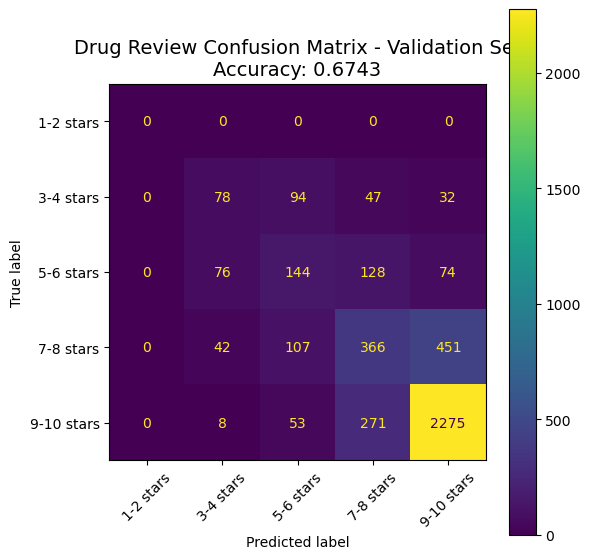

Detailed predictions saved: ./predictions_validation.csv

SUMMARY
Dataset: Validation
Total samples: 5541
Valid predictions: 4246 (76.6%)
Accuracy on valid predictions: 0.6743
Correct predictions: 2863/4246

EVALUATING TEST SET
Processing 46108 samples...

Inference complete!

SAMPLE PREDICTIONS (First 20)
Index  True   Predicted    Status
----------------------------------------------------------------------
0      4      4            Correct 
1      3      4            InCorrect
2      4      4            Correct 
3      4      4            Correct 
4      1      4            InCorrect
5      2      3            InCorrect
6      4      4            Correct 
7      3      2            InCorrect
8             1            InCorrect
9                          Correct 
10     2      4            InCorrect
11            3            InCorrect
12     4                   InCorrect
13     4      4            Correct 
14     1                   InCorrect
15                         Correct 
16

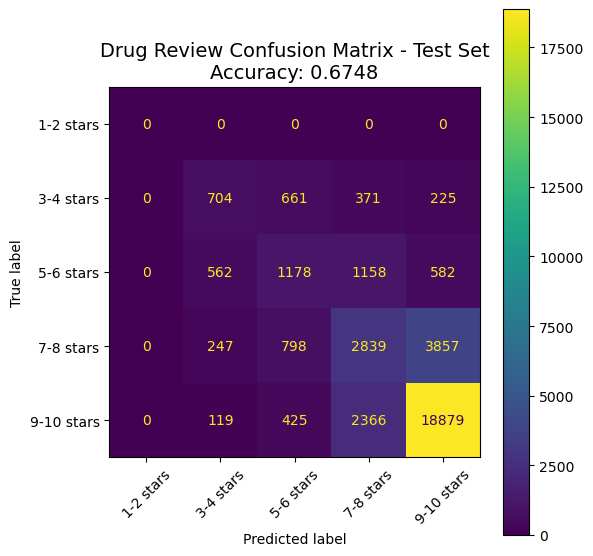

IndexError: single positional indexer is out-of-bounds

In [26]:

# ============================================================================
# RUN EVALUATION
# ============================================================================
print("\n" + "="*40)
print("STARTING EVALUATION")
print("="*40)

# Evaluate validation set
val_results = evaluate_dataset(
	model=model,
	tokenizer=tokenizer,
	dataset=tokenized_val,
	dataset_name="Validation",
	label_names=label_names,
	device=device,
	batch_size=16
)

# Evaluate test set
test_results = evaluate_dataset(
	model=model,
	tokenizer=tokenizer,
	dataset=tokenized_test,
	dataset_name="Test",
	label_names=label_names,
	device=device,
	batch_size=16
)

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("EVALUATION COMPLETE!")
print("="*70)

if val_results and test_results:
	print(f"\n Final Results:")
	print("*"*20)
	print(f"Validation Accuracy: {val_results['accuracy']:.4f}")
	print(f"Test Accuracy: {test_results['accuracy']:.4f}")
	print(f"\n Files saved in: {base_dir}")
	print(" Generated confusion_matrix_validation.png")
	print("Generated confusion_matrix_test.png")
	print("Generated predictions_validation.csv")
	print("Generated predictions_test.csv")
else:
	print("\nEvaluation encountered errors. Check the output above for details.")

# End Of File